TRAIN IMAGE
    ↓
Random Flip
    ↓
Small Rotation
    ↓
Small Color Variation
    ↓
Resize 224×224
    ↓
Tensor + Normalize

In [ ]:
import torch
import matplotlib.pyplot as plt
from torchvision import transforms, datasets
from pathlib import Path

In [ ]:


BASE_DIR = Path("..")

DATASET_DIR = BASE_DIR / "dataset"

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"

In [ ]:
train_transform = transforms.Compose([
    
    transforms.Resize((224, 224)),
    
    transforms.RandomHorizontalFlip(p=0.5),
    
    transforms.RandomVerticalFlip(p=0.5),
    
    transforms.RandomRotation(degrees=20),
    
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.05
    ),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
val_transform = transforms.Compose([
    
    transforms.Resize((224, 224)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=VAL_DIR,
    transform=val_transform
)

In [ ]:
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

print("\nClass mapping:")
print(train_dataset.class_to_idx)

Train: 8017
Validation: 1998

Class mapping:
{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [ ]:
def denormalize(image):
    
    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)
    
    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)
    
    image = image * std + mean
    
    return torch.clamp(image, 0, 1)

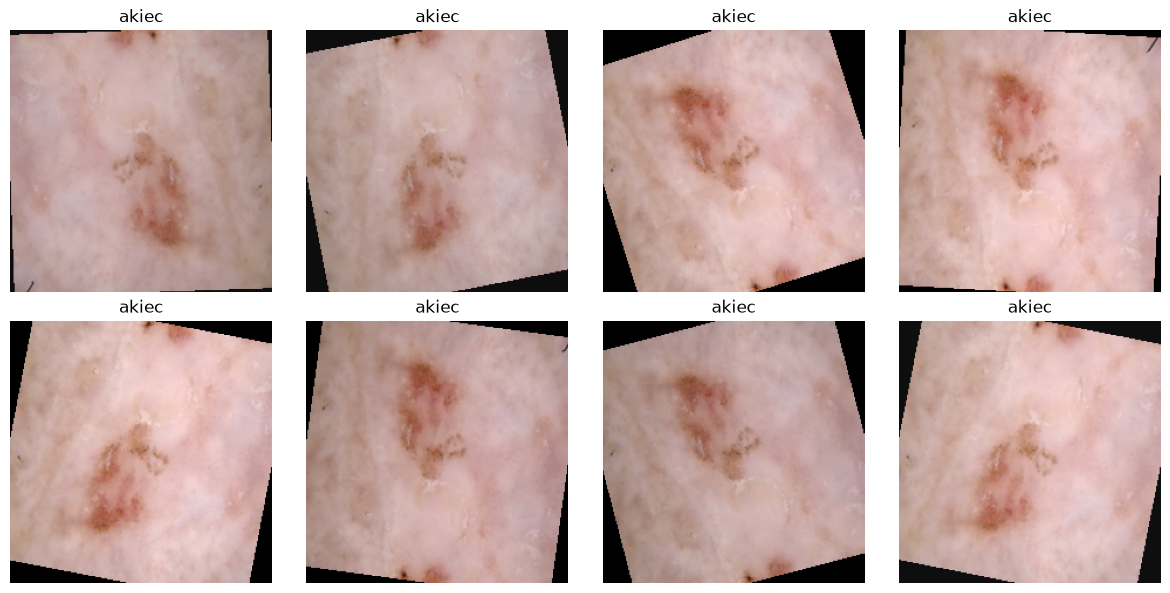

In [ ]:
index = 0

fig, axes = plt.subplots(
    2,
    4,
    figsize=(12, 6)
)

for ax in axes.flat:
    
    image, label = train_dataset[index]
    
    image = denormalize(image)
    
    image = image.permute(1, 2, 0)
    
    ax.imshow(image)
    
    ax.set_title(
        train_dataset.classes[label]
    )
    
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
image1, label1 = val_dataset[0]
image2, label2 = val_dataset[0]

difference = torch.abs(
    image1 - image2
).sum()

print("Difference:", difference.item())

Difference: 0.0


In [ ]:
assert len(train_dataset) == 8017
assert len(val_dataset) == 1998

assert (
    train_dataset.class_to_idx
    ==
    val_dataset.class_to_idx
)

print("=" * 55)
print("PHASE 9 COMPLETED SUCCESSFULLY")
print("=" * 55)

print("Training augmentation: ENABLED")
print("Validation augmentation: DISABLED")

print("\nTraining dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

print("\nClasses:")
print(train_dataset.classes)

PHASE 9 COMPLETED SUCCESSFULLY
Training augmentation: ENABLED
Validation augmentation: DISABLED

Training dataset: 8017
Validation dataset: 1998

Classes:
['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


Original Dataset
      │
      ├── TRAIN
      │     ↓
      │  Random Augmentation
      │     ↓
      │  Resize 224×224
      │     ↓
      │  Normalize
      │
      └── VALIDATION
            ↓
         Resize 224×224
            ↓
         Normalize